# Root Cause Analysis with an Unknown Causal Graph and a Hidden Confounder Using a Foundational Causal Discovery Model

Every graphical causal model (GCM) analysis starts the same way: *"First, define your causal graph."* But what if the causal graph is unknown?

This notebook demonstrates that a plain CSV of observed data can be sufficient: we infer the causal graph directly from
the data, learn the data generating process on top of it (the GCM) and then run the causal analyses. No prior knowledge
about the system's structure is required.

We look at a synthetic scenario of a **bottling line** in a beverage plant. The line streams nine sensor readings: mixer
speed and temperature, product viscosity, line speed, fill pressure, fill level, seal integrity, defect rate and
throughput. The sensors were added ad hoc over years and we assume there is no maintained wiring diagram of how
the stages influence each other.

Instead of defining the graph by hand, we can use causal discovery methods to infer it from observational data alone.
This is a notoriously hard problem. Observational data by itself does not uniquely determine a causal graph, so
'classical' discovery algorithms (see [causal-learn](https://github.com/py-why/causal-learn) for a broad collection) have to rely on
specific and often strong assumptions about the data generating process, such as linear relationships, additive noise
or particular distribution families. In practice, we rarely know whether these assumptions hold for our data, which
makes it unclear which algorithm to trust. Causal discovery foundation models take a different route: they are trained
on vast amounts of synthetic data covering a wide variety of generating processes and learn to map a dataset directly
to its causal graph. Rather than committing to one fixed set of assumptions, such a model has seen many kinds of causal
mechanisms during training. Here, we use [FoundCause](https://github.com/amazon-science/foundcause), a pretrained
foundation model for causal discovery that predicts the causal graph from raw observational data in a single forward
pass (see the related paper [Blöbaum, Balasubramanian & Kasiviswanathan, 2026](https://arxiv.org/abs/2606.17516) for
details). To make the scenario more challenging and realistic, our example even contains a *hidden confounder*: a
variable that influences several sensors but is itself not part of the recorded data. As we will see, the GCM-based
analyses remain robust in its presence. We use DoWhy's GCM module on the *discovered* graph to answer real production
questions:

1. **Discover** the causal graph of the line from sensor data alone and evaluate it against the ground truth (which we
   know in this notebook).
2. **Falsify**: test the discovered graph against the data with `falsify_graph` before trusting it.
3. **Root cause analysis**: attribute a sudden defect-rate spike to the responsible upstream sensor.
4. **Distribution change**: explain why throughput *dropped* after operations increased the line speed.

Because the data is simulated from a ground-truth structural causal model (built with DoWhy's own random SCM
generator), we can honestly verify every answer.

**A note of caution.** Causal discovery produces a *hypothesis* about the causal structure, not a verified ground
truth. FoundCause assumes i.i.d. observational data and, like every causal discovery method, can still get edges wrong,
most often their *orientation* (the paper reports that adjacency detection stays reliable while orientation accuracy
drops as the number of variables grows). It was trained on graphs with 2 to 50 variables, and it is unclear how well it
generalizes beyond that range. Always treat the discovered graph as a starting point to be validated, which we do below
in Step 2 with `falsify_graph`, and sanity-check it against domain knowledge before trusting any downstream result.

⚠️ **Model download required.** This notebook uses the FoundCause inference code and its pretrained weights
(**~1.6 GB**), which are downloaded from the official GitHub release the first time the notebook is executed. Both
files are cached in a `foundcause_model` folder next to this notebook, so subsequent runs load them from disk.
FoundCause runs on [PyTorch](https://pytorch.org/) (install with `pip install torch` if it is not already available).
Inference runs on CPU (no GPU required); the discovery step takes about 30 seconds per run on a laptop.

In [1]:
import hashlib
import os
import sys
import urllib.request

FOUNDCAUSE_DIR = "foundcause_model"
FILES = {
    "foundcause.py": (
        "https://raw.githubusercontent.com/amazon-science/foundcause/v1.0/foundcause.py",
        "43f2be8680cc90790a0322b6774b6969505f454f271c597ce418f935448ed663",
    ),
    "checkpoint.pt": (
        "https://github.com/amazon-science/foundcause/releases/download/v1.0/checkpoint.pt",
        "a24b6b4b5fd0d380361d4a0699b2ec993a6aa2da91f90bb384a383e01f55cb17",
    ),
}

os.makedirs(FOUNDCAUSE_DIR, exist_ok=True)
for filename, (url, sha256) in FILES.items():
    path = os.path.join(FOUNDCAUSE_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, path)
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    digest = digest.hexdigest()
    if digest != sha256:
        os.remove(path)
        raise RuntimeError(f"SHA-256 mismatch for {filename}; deleted the file, please re-run this cell.")
    print(f"{filename}: OK")

sys.path.insert(0, FOUNDCAUSE_DIR)

foundcause.py: OK


checkpoint.pt: OK


## Step 1: Simulate the bottling line

We first need a plant to analyze. We define the *true* causal structure of the line (the causal graph nobody at the
plant knows) and let DoWhy's random SCM generator (`dowhy.gcm.data_generator`) assign a random causal mechanism to
every node. This gives us a ground truth to grade the discovery against later.

The line works as follows: a **mixer** (speed, temperature) determines the product **viscosity**. Viscosity and the
**line speed** drive the **fill pressure**, which in turn determines the **fill level** of each bottle. The sealing
station's **seal integrity** and the fill level determine the **defect rate**. Defects together with line speed
determine the final **throughput**.

There is one more variable: **ambient humidity** affects both viscosity and seal integrity. Crucially, the plant has
*no humidity sensor*, so this variable exists physically but is not logged. This makes it a **hidden confounder**: it
influences two of the recorded sensors while being unobserved itself. Keep it in mind when we look at the discovered
graph.

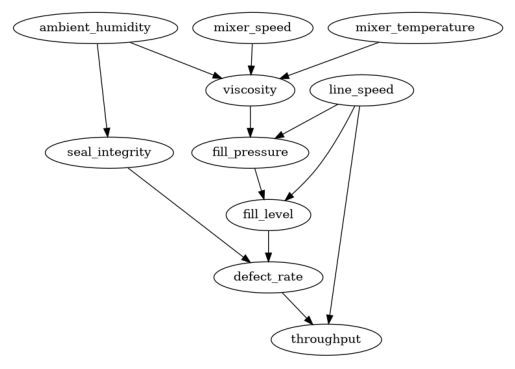

In [2]:
import networkx as nx
import numpy as np
import pandas as pd

from dowhy import gcm
from dowhy.gcm.util.general import set_random_seed
from dowhy.utils import bar_plot, plot

set_random_seed(0)

causal_graph_true = nx.DiGraph(
    [
        ("mixer_speed", "viscosity"),
        ("mixer_temperature", "viscosity"),
        ("ambient_humidity", "viscosity"),
        ("ambient_humidity", "seal_integrity"),
        ("viscosity", "fill_pressure"),
        ("line_speed", "fill_pressure"),
        ("fill_pressure", "fill_level"),
        ("line_speed", "fill_level"),
        ("fill_level", "defect_rate"),
        ("seal_integrity", "defect_rate"),
        ("defect_rate", "throughput"),
        ("line_speed", "throughput"),
    ]
)
plot(causal_graph_true)

Now we assign random causal mechanisms to this graph and draw observational samples. Two generator settings are
adjusted for this scenario: `prob_discretised=0` (the sensor readings are continuous) and `prob_non_additive_noise=0`
(keeps the ground truth an additive noise model to simplify the overall setting here). Everything else, such as which nodes get linear vs. neural network mechanisms and the
noise distributions, is up to the generator.

One variable is special: the line speed is not a free-floating measurement but an operator-selected *set-point*, so we
replace its root distribution with a discrete one taking five levels. The generator produces standardized values, so
we map each column to realistic engineering units (RPM, °C, cP, bar, mL, N, defects per 10k bottles, units/hour) to
make the dataset look like an actual production export.

In [3]:
from scipy import stats

from dowhy.gcm import ScipyDistribution
from dowhy.gcm.data_generator import DataGeneratorConfig, assign_random_fcms

scm_ground_truth = assign_random_fcms(
    causal_graph_true,
    DataGeneratorConfig(
        prob_discretised=0.0,
        prob_non_additive_noise=0.0,
        prob_linear_mechanism=0.5,
        prob_clipped_positive=0.0,
        prob_clipped_negative=0.0,
    ),
)

# line_speed is an operator-selected set-point: one of five discrete levels
scm_ground_truth.set_causal_mechanism("line_speed", ScipyDistribution(stats.randint, low=-2, high=3))

# offset and scale per column: standardized simulator output -> engineering units
ENGINEERING_UNITS = {
    "mixer_speed": (120.0, 12.0),  # RPM
    "mixer_temperature": (78.0, 3.5),  # deg C
    "ambient_humidity": (55.0, 8.0),  # % relative humidity
    "line_speed": (220.0, 20.0),  # bottles/min, set-points 180/200/220/240/260
    "viscosity": (350.0, 45.0),  # centipoise
    "fill_pressure": (2.8, 0.35),  # bar
    "fill_level": (500.0, 6.0),  # mL
    "seal_integrity": (55.0, 7.0),  # N (seal peel force)
    "defect_rate": (50.0, 12.0),  # defects per 10k bottles
    "throughput": (12600.0, 900.0),  # units/hour
}


def to_engineering_units(df):
    df = df.copy()
    for column, (offset, scale) in ENGINEERING_UNITS.items():
        if column in df.columns:
            df[column] = offset + scale * df[column]
    return df


full_plant_data = to_engineering_units(gcm.draw_samples(scm_ground_truth, 2000))

# The plant has no humidity sensor: the logged data does not contain this column!
sensor_data = full_plant_data.drop(columns=["ambient_humidity"])
sensor_data.head()

,mixer_speed,mixer_temperature,line_speed,viscosity,seal_integrity,fill_pressure,fill_level,defect_rate,throughput
0,116.867980,78.892194,180.0,357.285662,51.900159,3.067862,504.893093,41.097644,13921.087928
1,117.252561,80.514292,180.0,381.689183,47.309436,3.034114,505.603533,55.119948,13144.673325
2,130.733961,78.061188,180.0,354.826741,51.863390,3.031115,505.085935,46.514953,13564.054101
3,129.330948,79.109797,260.0,334.043557,60.704776,2.526425,494.317042,52.638996,11789.818855
4,112.324039,79.665473,220.0,335.089970,59.163353,2.624241,500.932726,45.692243,12736.843368


In [4]:
sensor_data.describe().loc[["mean", "std", "min", "max"]].round(1).T

,mean,std,min,max
mixer_speed,120.0,12.1,79.0,164.0
mixer_temperature,78.1,3.3,67.2,90.3
line_speed,219.9,28.7,180.0,260.0
viscosity,339.1,14.4,303.5,395.4
seal_integrity,54.9,3.9,42.5,68.0
fill_pressure,2.8,0.3,2.5,3.2
fill_level,500.0,3.5,493.5,506.2
defect_rate,50.3,10.0,23.0,84.7
throughput,12588.4,993.0,9810.9,15007.8


Finally, we generate the data for two events that we will investigate later in the notebook, both created from the
ground-truth SCM via interventions:

- **A quality incident**: the sealing unit degrades and its seal force drops by four standard deviations. We will see
  this as a defect-rate spike and root-cause it in Step 5.
- **A process change**: operations raises the line-speed set-point by one level. We will analyze its surprising effect
  on throughput in Step 6.

In [5]:
from dowhy.gcm.whatif import interventional_samples

# quality incident: the sealing unit degrades (seal force drops by 4 standard deviations)
seal_drop = 4.0 * sensor_data["seal_integrity"].std() / ENGINEERING_UNITS["seal_integrity"][1]
incident_data = to_engineering_units(
    interventional_samples(
        scm_ground_truth,
        {"seal_integrity": lambda x: x - seal_drop},
        num_samples_to_draw=3,
    )
).drop(columns=["ambient_humidity"])

# process change: line-speed set-point raised by one level (+20 bottles/min),
# clamped so it stays within the five available set-points (up to 260 bottles/min)
data_after_speedup = to_engineering_units(
    interventional_samples(
        scm_ground_truth,
        {"line_speed": lambda x: np.minimum(x + 1, 2)},
        num_samples_to_draw=3000,
    )
).drop(columns=["ambient_humidity"])

The ground truth has now served its purpose. From here on, everything works exclusively with the exported data: the
historical `sensor_data`, the three `incident_data` snapshots and the `data_after_speedup` export. We pretend to have
no knowledge of the graph or the mechanisms that generated them.

## Step 2: Discover the causal graph with FoundCause

FoundCause is a ~139M-parameter transformer trained entirely on synthetic data to map a dataset (samples × variables)
directly to a causal graph: no per-dataset training, no independence tests to configure, just a forward pass. Keep
the assumptions and limits from the note in the introduction in mind.

We load the pretrained checkpoint and wrap the model's `predict` function into a small helper that returns the
discovered graph as a `networkx.DiGraph`. Since FoundCause does not guarantee acyclicity, we apply the greedy DAG
post-processing from the official repository (`predict.py`), which inserts edges in order of decreasing probability
while skipping any edge that would create a cycle. A DAG is exactly what `dowhy.gcm` needs downstream.

In [6]:
import torch
from foundcause import CausalDiscoveryTransformer, ModelConfig, predict

device = torch.device("cpu")
foundcause_model = CausalDiscoveryTransformer(ModelConfig())
checkpoint = torch.load(
    os.path.join(FOUNDCAUSE_DIR, "checkpoint.pt"), map_location=device, weights_only=False
)
state = {k.replace("_orig_mod.", ""): v for k, v in checkpoint["model_state_dict"].items()}
foundcause_model.load_state_dict(state, strict=False)
foundcause_model.eval()
print("FoundCause model loaded.")

FoundCause model loaded.


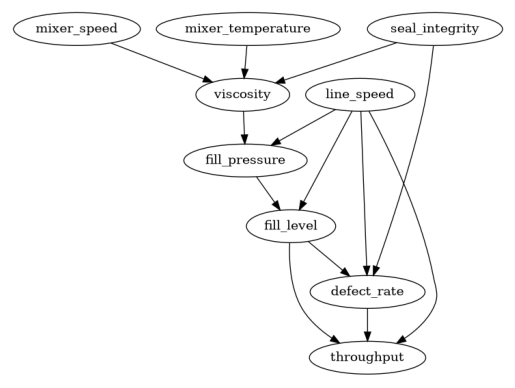

In [7]:
def enforce_dag(edge_probabilities, threshold):
    """Greedy DAG post-processing from the official FoundCause predict.py: add edges in
    descending probability order, skipping any that would create a cycle."""
    num_nodes = edge_probabilities.shape[0]
    candidates = [
        (edge_probabilities[i, j], i, j)
        for i in range(num_nodes)
        for j in range(num_nodes)
        if i != j and edge_probabilities[i, j] > threshold
    ]
    candidates.sort(reverse=True)
    graph = nx.DiGraph()
    graph.add_nodes_from(range(num_nodes))
    adjacency = np.zeros_like(edge_probabilities)
    for _, i, j in candidates:
        if nx.has_path(graph, j, i):
            continue
        graph.add_edge(i, j)
        adjacency[i, j] = 1.0
    return adjacency


def discover_graph(data):
    """Run FoundCause on a DataFrame and return the discovered DAG."""
    X = data.to_numpy().astype(np.float32)
    variable_names = list(data.columns)

    result = predict(foundcause_model, X, device)
    adjacency = enforce_dag(result["probabilities"], result["threshold"])

    discovered = nx.DiGraph()
    discovered.add_nodes_from(variable_names)
    for i, source in enumerate(variable_names):
        for j, target in enumerate(variable_names):
            if adjacency[i, j]:
                discovered.add_edge(source, target)
    return discovered


causal_graph_discovered = discover_graph(sensor_data)
plot(causal_graph_discovered)

⚠️ **The discovered graph is a hypothesis, not ground truth.** FoundCause does not guarantee correctness (or even
acyclicity, which is why we post-process into a DAG above). It tends to recover the skeleton (which variables are
connected) more reliably than the exact edge directions. Before relying on it, validate the graph, ideally by combining
the falsification test in the next step with domain expertise.

That is the entire discovery step: within a few seconds, we recovered a causal graph from the observed data with a
single function call on the raw sensor DataFrame. The result is
not perfect though. Since we know the true graph in this notebook, we can grade it.

In [8]:
true_edges = set(
    (source, target) for source, target in causal_graph_true.edges if "ambient_humidity" not in (source, target)
)
discovered_edges = set(causal_graph_discovered.edges)

correct = discovered_edges & true_edges
extra = discovered_edges - true_edges
missed = true_edges - discovered_edges

print(f"True edges among logged sensors: {len(true_edges)}")
print(f"Recovered: {len(correct)}/{len(true_edges)} (recall {len(correct) / len(true_edges):.0%}, "
      f"precision {len(correct) / len(discovered_edges):.0%})")
print(f"\nMissed edges: {sorted(missed) if missed else 'none'}")
print("Extra edges:")
for source, target in sorted(extra):
    print(f"  {source} -> {target}")

True edges among logged sensors: 10
Recovered: 10/10 (recall 100%, precision 77%)

Missed edges: none
Extra edges:
  fill_level -> throughput
  line_speed -> defect_rate
  seal_integrity -> viscosity


FoundCause recovered **every true edge** of the production line, with none missed and none pointing in the wrong
direction. It added a few edges that are not part of the true graph, mostly "shortcuts" along strong causal pathways
(e.g. `fill_pressure -> throughput` parallels the true path through `fill_level` and `defect_rate`). As long as such
additional edges are not wrongly directed but reflect the causal order, this is usually fine, which is the case here.
Since we fit a causal mechanism for each node given its parents, a superfluous parent simply ends up contributing
(close to) nothing to the fitted mechanism; the mechanism learns which parents actually matter. Missing or reversed
edges are more harmful, because they remove or distort causal pathways that no amount of fitting can recover.

The edge between `seal_integrity` and `viscosity` deserves a remark. Physically, the sealing station cannot influence
the viscosity of the liquid; this dependence is induced by the **hidden confounder**, since ambient humidity affects
both variables but is not logged. We keep the graph as it is. As the following analyses show, the GCM-based methods
remain robust against this artifact of the hidden confounder.

## Step 3: Falsify the discovered graph before trusting it

A discovered graph should not be taken on faith, especially not for production decisions. DoWhy provides a
permutation-based falsification test ([Eulig et al., 2023](https://arxiv.org/abs/2305.09565)) that checks whether the
given DAG explains the conditional-independence structure of the data significantly better than random graphs over the
same nodes.

/home/runner/.cache/pypoetry/virtualenvs/dowhy-n6DJFijf-py3.9/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Test permutations of given graph:   0%|          | 0/20 [00:00<?, ?it/s]

Test permutations of given graph:   5%|▌         | 1/20 [00:57<18:16, 57.72s/it]

Test permutations of given graph:  10%|█         | 2/20 [01:52<16:45, 55.89s/it]

Test permutations of given graph:  15%|█▌        | 3/20 [02:46<15:39, 55.28s/it]

...

Test permutations of given graph:  85%|████████▌ | 17/20 [14:13<02:15, 45.12s/it]

Test permutations of given graph:  90%|█████████ | 18/20 [14:46<01:22, 41.47s/it]

Test permutations of given graph:  95%|█████████▌| 19/20 [15:32<00:43, 43.07s/it]

Test permutations of given graph: 100%|██████████| 20/20 [16:18<00:00, 43.69s/it]

Test permutations of given graph: 100%|██████████| 20/20 [16:18<00:00, 48.90s/it]

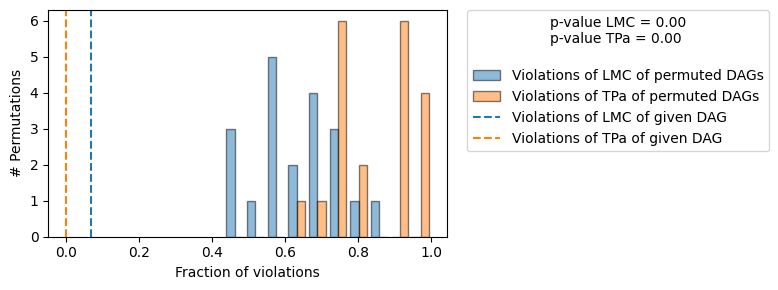

+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 2/30 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00).      |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we do not reject the DAG.                                                                             |
+-------------------------------------------------------------------------------------------------------+

In [9]:
from dowhy.gcm.falsify import falsify_graph

falsification_result = falsify_graph(causal_graph_discovered, sensor_data, n_permutations=20, plot_histogram=True)
falsification_result

The test does **not reject** the discovered DAG: it is informative (no random permutation of it entails the same
independencies) and violates far fewer local Markov conditions than random graphs. We now have a machine-discovered,
data-validated causal graph obtained without manually defining a single edge and can proceed to actual causal queries.

## Step 4: Fit a GCM on the discovered graph

We fit an invertible structural causal model on the discovered graph, letting DoWhy pick a suitable causal mechanism
for every node automatically. This learns the data generating process from the sensor CSV alone.

In [10]:
scm_discovered = gcm.InvertibleStructuralCausalModel(causal_graph_discovered)
summary = gcm.auto.assign_causal_mechanisms(scm_discovered, sensor_data)
gcm.fit(scm_discovered, sensor_data)

Fitting causal models:   0%|          | 0/9 [00:00<?, ?it/s]

Fitting causal mechanism of node mixer_speed:   0%|          | 0/9 [00:00<?, ?it/s]

Fitting causal mechanism of node mixer_temperature:   0%|          | 0/9 [00:00<?, ?it/s]

Fitting causal mechanism of node line_speed:   0%|          | 0/9 [00:00<?, ?it/s]       

Fitting causal mechanism of node viscosity:   0%|          | 0/9 [00:00<?, ?it/s] 

...

Fitting causal mechanism of node fill_level:  44%|████▍     | 4/9 [00:00<00:00, 20.69it/s]   

Fitting causal mechanism of node fill_level:  78%|███████▊  | 7/9 [00:00<00:00, 17.64it/s]

Fitting causal mechanism of node defect_rate:  78%|███████▊  | 7/9 [00:00<00:00, 17.64it/s]

Fitting causal mechanism of node throughput:  78%|███████▊  | 7/9 [00:00<00:00, 17.64it/s] 

Fitting causal mechanism of node throughput: 100%|██████████| 9/9 [00:00<00:00, 22.87it/s]

## Step 5: Root cause analysis of a defect-rate spike

Recall the quality incident we generated in Step 1: the sealing unit degraded and its seal force dropped by four
standard deviations. On the quality dashboard, this materializes as three production snapshots with a defect rate far
above normal. The plant team sees only these sensor readings:

In [11]:
comparison = pd.DataFrame(
    {"incident (mean of 3)": incident_data.mean().round(1), "normal (mean)": sensor_data.mean().round(1)}
)
comparison

,incident (mean of 3),normal (mean)
mixer_speed,130.9,120.0
mixer_temperature,77.9,78.1
line_speed,226.7,219.9
viscosity,349.1,339.1
seal_integrity,36.4,54.9
fill_pressure,2.8,2.8
fill_level,498.9,500.0
defect_rate,86.8,50.3
throughput,10319.1,12588.4


Which part of the line is responsible for the elevated defect rate? We answer this with `attribute_anomalies`.
Note that everything used in this analysis is learned from data: the causal graph came from FoundCause and the causal
mechanisms were fitted on the sensor CSV. The ground-truth SCM played no role beyond generating the data.

Evaluating set functions...:   0%|          | 0/120 [00:00<?, ?it/s]

Evaluating set functions...:   7%|▋         | 8/120 [00:00<00:06, 16.58it/s]

Evaluating set functions...:  10%|█         | 12/120 [00:01<00:09, 11.08it/s]

Evaluating set functions...:  13%|█▎        | 16/120 [00:01<00:10,  9.68it/s]

Evaluating set functions...:  17%|█▋        | 20/120 [00:02<00:11,  8.88it/s]

...

Evaluating set functions...:  90%|█████████ | 108/120 [00:13<00:01,  7.58it/s]

Evaluating set functions...:  93%|█████████▎| 112/120 [00:14<00:01,  7.77it/s]

Evaluating set functions...:  97%|█████████▋| 116/120 [00:14<00:00,  7.42it/s]

Evaluating set functions...: 100%|██████████| 120/120 [00:15<00:00,  7.63it/s]

Evaluating set functions...: 100%|██████████| 120/120 [00:15<00:00,  7.86it/s]

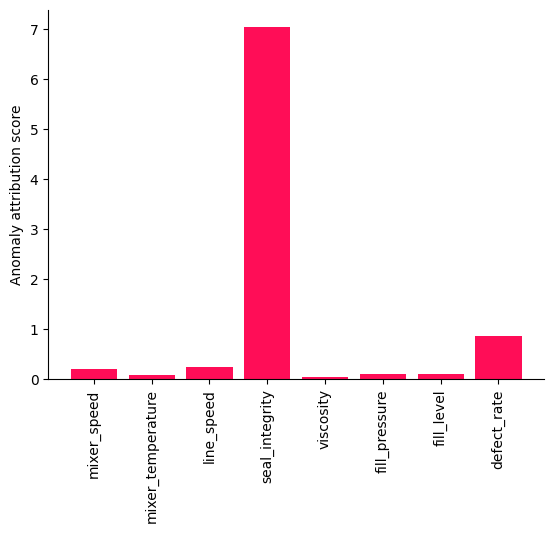

In [12]:
attributions = gcm.attribute_anomalies(scm_discovered, "defect_rate", anomaly_samples=incident_data)

bar_plot({node: scores.mean() for node, scores in attributions.items()}, ylabel="Anomaly attribution score")

The attribution correctly identifies **`seal_integrity`** as the dominant root cause of the defect spike: the
sealing unit, exactly where we injected the degradation.

## Step 6: Distribution change: why did the line speed-up backfire?

Now to the second event from Step 1: operations raised the line-speed set-point by one level to catch up with demand.
Counterintuitively, throughput *dropped*. Management wants to know what changed in the system.

In [13]:
print(f"line_speed:  {sensor_data['line_speed'].mean():.0f} -> {data_after_speedup['line_speed'].mean():.0f} bottles/min")
print(f"throughput:  {sensor_data['throughput'].mean():.0f} -> {data_after_speedup['throughput'].mean():.0f} units/hour")

line_speed:  220 -> 236 bottles/min
throughput:  12588 -> 12109 units/hour


`distribution_change` compares the historical export against the new one and attributes the change in the
throughput distribution to the nodes whose causal mechanisms actually changed between the two datasets. Again, this
analysis runs entirely on the discovered graph and the observed data.

Evaluating set functions...:   0%|          | 0/155 [00:00<?, ?it/s]

Evaluating set functions...:   5%|▌         | 8/155 [00:00<00:02, 63.08it/s]

Evaluating set functions...:  10%|█         | 16/155 [00:00<00:04, 28.90it/s]

Evaluating set functions...:  15%|█▌        | 24/155 [00:00<00:04, 29.72it/s]

Evaluating set functions...:  21%|██        | 32/155 [00:01<00:04, 28.02it/s]

...

Evaluating set functions...:  83%|████████▎ | 128/155 [00:04<00:01, 25.36it/s]

Evaluating set functions...:  88%|████████▊ | 136/155 [00:05<00:00, 25.85it/s]

Evaluating set functions...:  93%|█████████▎| 144/155 [00:05<00:00, 26.44it/s]

Evaluating set functions...:  98%|█████████▊| 152/155 [00:05<00:00, 26.10it/s]

Evaluating set functions...: 100%|██████████| 155/155 [00:05<00:00, 27.23it/s]

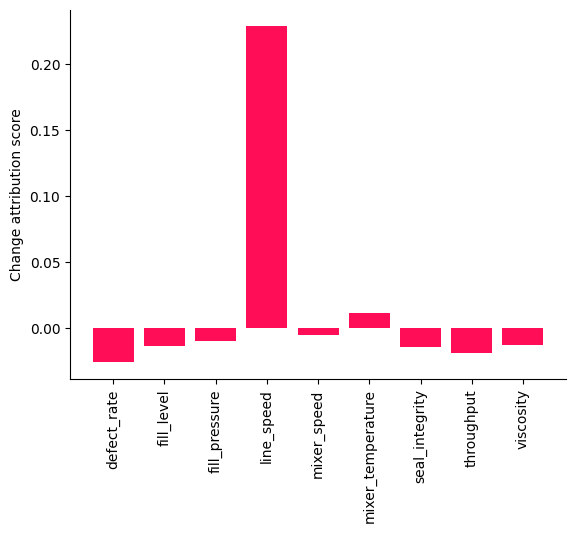

In [14]:
change_attributions = gcm.distribution_change(
    gcm.ProbabilisticCausalModel(causal_graph_discovered), sensor_data, data_after_speedup, "throughput"
)

bar_plot(change_attributions, ylabel="Change attribution score")

The analysis attributes the throughput change to the **`line_speed`** mechanism (the set-point change) and not to
any downstream mechanism. In other words: nothing on the line is broken; the speed-up itself backfired. The discovered
graph explains why: `line_speed` raises `defect_rate` (via the fill dynamics) and the additional defects
more than offset the faster line.

## Conclusion

All we started with was a CSV export of sensor readings. From that single artifact, we inferred the causal graph with
a foundation model, learned the data generating process on top of it and answered real production questions: graph
falsification, root cause analysis and distribution-change attribution, **without manually defining a single causal
edge**. Because we simulated the plant with DoWhy's random SCM generator, every answer could be verified against
ground truth, including robustness of the analyses to a hidden confounder.

A few notes:

- **Discovery is not perfect.** FoundCause recovered all true edges here but added extra ones. The fitted causal
  mechanisms are fairly robust to superfluous parents, but you should still validate a discovered graph with
  `falsify_graph`, with domain experts, or both, before making decisions with it.
- **Hidden confounders matter.** An unlogged common cause showed up as a physically impossible edge in the discovered
  graph. The downstream analyses were robust to it here, but treat such artifacts as a signal to look for missing
  variables, not as noise.
- **Foundation models are not the only option.** If more details about the data generation process are known, certain
  causal discovery algorithms that explicitly exploit these asymmetries could be a better fit. For example, if the
  relationships are known to be linear with non-Gaussian noise, or to follow an additive noise model, algorithms
  tailored to exactly these assumptions (see [causal-learn](https://github.com/py-why/causal-learn) for a broad collection of such algorithms) can
  use that knowledge in ways a general-purpose model cannot. A foundation model like
  [FoundCause](https://github.com/amazon-science/foundcause)
  ([Blöbaum, Balasubramanian & Kasiviswanathan, 2026](https://arxiv.org/abs/2606.17516)) shines when such knowledge is
  not available.
- **Seeds.** This notebook fixes the random seed once at the beginning for reproducibility. Different seeds might lead
  to slightly different results due to the strong randomness in the data generation process.